## Logistic Regression Models

Now we fit three logistic regression models for comparison:
1. **Null Model** - Intercept only (baseline)
2. **Basic Model** - Single predictor (Lead Time)
3. **Full Model** - All features with class weights

In [53]:
# Import statsmodels for GLM
import statsmodels.api as sm
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, roc_auc_score, brier_score_loss,
                              confusion_matrix, classification_report, roc_curve)
from sklearn.calibration import calibration_curve
from scipy import stats

In [54]:
# Load the train/test data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load data from CSV files
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()  # Convert to Series
y_test = pd.read_csv('../data/y_test.csv').squeeze()    # Convert to Series

print("Data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("\nFeatures:")
print(X_train.columns.tolist())

Data loaded successfully!
X_train shape: (79503, 9)
X_test shape: (20201, 9)
y_train shape: (79503,)
y_test shape: (20201,)

Features:
['Domestic', 'TripReason', 'Vehicle', 'LogPrice', 'LogLeadTime', 'TimeOfDay', 'From_Encoded', 'To_Encoded', 'Route_Encoded']


### Null Model (Intercept Only)

The null model predicts the same probability (global mean) for everyone.

In [55]:
# Null Model (Intercept Only) - weighted
print("="*60)
print("BASELINE MODEL: INTERCEPT ONLY (NULL MODEL) - weighted")
print("="*60)

# Reset indices to align data
y_train_reset = y_train.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Calculate class weights (inverse frequency)
n_samples = len(y_train_reset)
n_pos = y_train_reset.sum()
n_neg = n_samples - n_pos
weight_pos = n_samples / (2 * n_pos)
weight_neg = n_samples / (2 * n_neg)
sample_weights = np.where(y_train_reset == 1, weight_pos, weight_neg)

print(f"Class weights: Negative={weight_neg:.3f}, Positive={weight_pos:.3f}")

# Fit null model (intercept only) with class weights
X_train_null = pd.DataFrame({'const': np.ones(len(y_train_reset))})
X_test_null = pd.DataFrame({'const': np.ones(len(y_test_reset))})

null_model = sm.GLM(
    y_train_reset, 
    X_train_null, 
    family=sm.families.Binomial(),
    freq_weights=sample_weights
).fit()

print(null_model.summary())

# Predictions
y_pred_prob_null = null_model.predict(X_test_null)
y_pred_null = (y_pred_prob_null >= 0.5).astype(int)

print(f"\nNull Model Test Metrics:")
print(f"ROC-AUC: {roc_auc_score(y_test_reset, y_pred_prob_null):.4f}")

BASELINE MODEL: INTERCEPT ONLY (NULL MODEL) - weighted
Class weights: Negative=0.580, Positive=3.630
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Cancel   No. Observations:                79503
Model:                            GLM   Df Residuals:                 79502.00
Model Family:                Binomial   Df Model:                            0
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -55107.
Date:                Sat, 31 Jan 2026   Deviance:                   1.1021e+05
Time:                        09:52:16   Pearson chi2:                 7.95e+04
No. Iterations:                     2   Pseudo R-squ. (CS):          2.220e-16
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

### Basic Model (Single Feature - LogLeadTime)

Test if lead time alone has predictive power.

In [56]:
# Basic Model - LogLeadTime Only (with class weights)
print("="*60)
print("BASIC MODEL: LogLeadTime Only (weighted)")
print("="*60)

X_train_basic = sm.add_constant(X_train_scaled[['LogLeadTime']])
X_test_basic = sm.add_constant(X_test_scaled[['LogLeadTime']])

# Calculate class weights (inverse frequency)
n_samples = len(y_train_reset)
n_pos = y_train_reset.sum()
n_neg = n_samples - n_pos
weight_pos = n_samples / (2 * n_pos)
weight_neg = n_samples / (2 * n_neg)
sample_weights = np.where(y_train_reset == 1, weight_pos, weight_neg)

basic_model = sm.GLM(
    y_train_reset, 
    X_train_basic, 
    family=sm.families.Binomial(),
    freq_weights=sample_weights
).fit()

print(basic_model.summary())

# Predictions
y_pred_prob_basic = basic_model.predict(X_test_basic)
y_pred_basic = (y_pred_prob_basic >= 0.5).astype(int)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_basic = [
    accuracy_score(y_test_reset, y_pred_basic),
    precision_score(y_test_reset, y_pred_basic),
    recall_score(y_test_reset, y_pred_basic),
    f1_score(y_test_reset, y_pred_basic),
    roc_auc_score(y_test_reset, y_pred_prob_basic)
]

comparison_df = pd.DataFrame({
    'Metric': metrics,
    'Threshold=0.5': results_basic,
})

print(comparison_df.to_string(index=False))

print(f"\nBasic Model Test Metrics:")
print(f"ROC-AUC: {roc_auc_score(y_test_reset, y_pred_prob_basic):.4f}")

# Likelihood Ratio Test vs Null
lr_stat = 2 * (basic_model.llf - null_model.llf)
lr_pvalue = 1 - stats.chi2.cdf(lr_stat, df=1)
print(f"\nLikelihood Ratio Test vs Null:")
print(f"LR Statistic: {lr_stat:.2f}, p-value: {lr_pvalue:.4e}")

BASIC MODEL: LogLeadTime Only (weighted)
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Cancel   No. Observations:                79503
Model:                            GLM   Df Residuals:                 79501.00
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -53634.
Date:                Sat, 31 Jan 2026   Deviance:                   1.0727e+05
Time:                        09:52:16   Pearson chi2:                 7.95e+04
No. Iterations:                     4   Pseudo R-squ. (CS):            0.03638
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const    

### Full Model (All Features with Class Weights)

Fit with all features using class weights to handle imbalance.

In [57]:
# Full Model with Class Weights
print("="*60)
print("FULL MODEL (All Features)")
print("="*60)

# Add constant to feature matrices
X_train_const = sm.add_constant(X_train_scaled)
X_test_const = sm.add_constant(X_test_scaled)

# Calculate class weights (inverse frequency)
n_samples = len(y_train_reset)
n_pos = y_train_reset.sum()
n_neg = n_samples - n_pos
weight_pos = n_samples / (2 * n_pos)
weight_neg = n_samples / (2 * n_neg)

# Create sample weights
sample_weights = np.where(y_train_reset == 1, weight_pos, weight_neg)

print(f"Class weights: Negative={weight_neg:.3f}, Positive={weight_pos:.3f}")

# Fit weighted logistic regression
full_model = sm.GLM(
    y_train_reset, 
    X_train_const, 
    family=sm.families.Binomial(),
    freq_weights=sample_weights
).fit()

print(full_model.summary())

FULL MODEL (All Features)
Class weights: Negative=0.580, Positive=3.630
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Cancel   No. Observations:                79503
Model:                            GLM   Df Residuals:                 79493.00
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -53220.
Date:                Sat, 31 Jan 2026   Deviance:                   1.0644e+05
Time:                        09:52:17   Pearson chi2:                 7.96e+04
No. Iterations:                     4   Pseudo R-squ. (CS):            0.04638
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

### Model Evaluation and Comparison

In [58]:
# Model Evaluation
print("="*60)
print("MODEL EVALUATION")
print("="*60)

# Predictions from full model
y_pred_prob_full = full_model.predict(X_test_const)

# Predictions 
y_pred_05 = (y_pred_prob_full >= 0.5).astype(int)


metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_05 = [
    accuracy_score(y_test_reset, y_pred_05),
    precision_score(y_test_reset, y_pred_05),
    recall_score(y_test_reset, y_pred_05),
    f1_score(y_test_reset, y_pred_05),
    roc_auc_score(y_test_reset, y_pred_prob_full)
]

comparison_df = pd.DataFrame({
    'Metric': metrics,
    'Threshold=0.5': results_05,
})
print(comparison_df.to_string(index=False))

# Confusion Matrix
print("\nConfusion Matrix (Threshold = 0.5):")
cm = confusion_matrix(y_test_reset, y_pred_05)
print(cm)
print("\nClassification Report:")
print(classification_report(y_test_reset, y_pred_05, target_names=['No Cancel', 'Cancel']))

MODEL EVALUATION
   Metric  Threshold=0.5
 Accuracy       0.607445
Precision       0.214076
   Recall       0.594842
 F1-Score       0.314844
  ROC-AUC       0.633795

Confusion Matrix (Threshold = 0.5):
[[10449  6689]
 [ 1241  1822]]

Classification Report:
              precision    recall  f1-score   support

   No Cancel       0.89      0.61      0.72     17138
      Cancel       0.21      0.59      0.31      3063

    accuracy                           0.61     20201
   macro avg       0.55      0.60      0.52     20201
weighted avg       0.79      0.61      0.66     20201



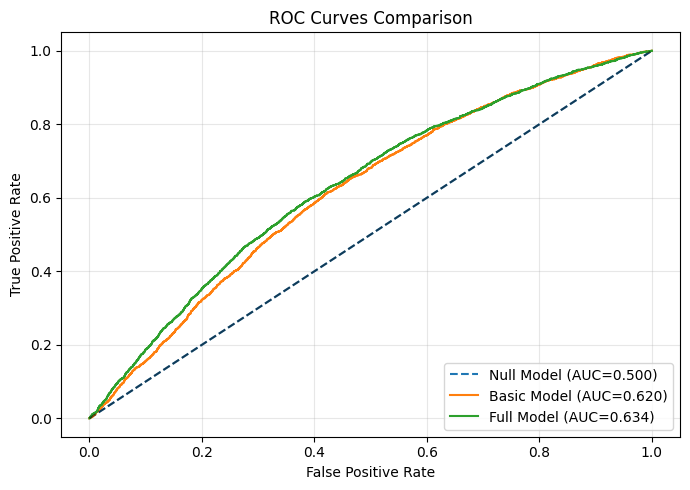

In [59]:
# ROC Curve Comparison
fig, axes = plt.subplots(1, 1, figsize=(7, 5))

# ROC Curve
ax1 = axes
fpr_null, tpr_null, _ = roc_curve(y_test_reset, y_pred_prob_null)
fpr_basic, tpr_basic, _ = roc_curve(y_test_reset, y_pred_prob_basic)
fpr_full, tpr_full, _ = roc_curve(y_test_reset, y_pred_prob_full)

ax1.plot(fpr_null, tpr_null, label=f'Null Model (AUC={roc_auc_score(y_test_reset, y_pred_prob_null):.3f})', linestyle='--')
ax1.plot(fpr_basic, tpr_basic, label=f'Basic Model (AUC={roc_auc_score(y_test_reset, y_pred_prob_basic):.3f})')
ax1.plot(fpr_full, tpr_full, label=f'Full Model (AUC={roc_auc_score(y_test_reset, y_pred_prob_full):.3f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves Comparison')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [60]:
# Final Model Comparison Summary
print("="*60)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*60)

# Fit unweighted full model for fair AIC/BIC comparison
full_model_unweighted = sm.GLM(
    y_train_reset, 
    X_train_const, 
    family=sm.families.Binomial()
).fit()

y_pred_prob_full_unweighted = full_model_unweighted.predict(X_test_const)

summary_data = {
    'Model': ['Null', 'Basic (LogLeadTime)', 'Full Model (unweighted)'],
    'AIC': [null_model.aic, basic_model.aic, full_model_unweighted.aic],
    'Log-Likelihood': [null_model.llf, basic_model.llf, full_model_unweighted.llf],
    'ROC-AUC': [
        roc_auc_score(y_test_reset, y_pred_prob_null),
        roc_auc_score(y_test_reset, y_pred_prob_basic),
        roc_auc_score(y_test_reset, y_pred_prob_full_unweighted)
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*60)
print("WEIGHTED MODEL RESULTS (for imbalanced data)")
print("="*60)
print(f"Full Model (weighted) ROC-AUC: {roc_auc_score(y_test_reset, y_pred_prob_full):.4f}")
print(f"Full Model (weighted) Recall: {recall_score(y_test_reset, y_pred_05):.4f}")
print(f"Full Model (weighted) F1-Score: {f1_score(y_test_reset, y_pred_05):.4f}")

FINAL MODEL COMPARISON SUMMARY
                  Model           AIC  Log-Likelihood  ROC-AUC
                   Null 110216.560592   -55107.280296 0.500000
    Basic (LogLeadTime) 107271.999506   -53633.999753 0.620269
Full Model (unweighted)  61990.986545   -30985.493272 0.633007

WEIGHTED MODEL RESULTS (for imbalanced data)
Full Model (weighted) ROC-AUC: 0.6338
Full Model (weighted) Recall: 0.5948
Full Model (weighted) F1-Score: 0.3148


## Additional Model Comparisons

### Reduced Model (Significant Features Only)

In [61]:
# Reduced Model - Remove non-significant features (From_Encoded, To_Encoded)
print("="*60)
print("REDUCED MODEL (Significant Features Only) - weighted")
print("="*60)

# Select only significant features
significant_features = ['Domestic', 'TripReason', 'Vehicle', 'LogPrice', 
                        'LogLeadTime', 'TimeOfDay', 'Route_Encoded']

X_train_reduced = sm.add_constant(X_train_scaled[significant_features])
X_test_reduced = sm.add_constant(X_test_scaled[significant_features])

# Fit reduced model with class weights
reduced_model = sm.GLM(
    y_train_reset, 
    X_train_reduced, 
    family=sm.families.Binomial(),
    freq_weights=sample_weights
).fit()

print(reduced_model.summary())

# Predictions
y_pred_prob_reduced = reduced_model.predict(X_test_reduced)
y_pred_reduced = (y_pred_prob_reduced >= 0.5).astype(int)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_reduced = [
    accuracy_score(y_test_reset, y_pred_reduced),
    precision_score(y_test_reset, y_pred_reduced),
    recall_score(y_test_reset, y_pred_reduced),
    f1_score(y_test_reset, y_pred_reduced),
    roc_auc_score(y_test_reset, y_pred_prob_reduced)
]

comparison_df = pd.DataFrame({
    'Metric': metrics,
    'Threshold=0.5': results_reduced,
})

print(comparison_df.to_string(index=False))

print(f"\nReduced Model Test Metrics:")
print(f"ROC-AUC: {roc_auc_score(y_test_reset, y_pred_prob_reduced):.4f}")

# Likelihood Ratio Test: Full vs Reduced
lr_stat_reduced = 2 * (full_model.llf - reduced_model.llf)
df_diff = full_model.df_model - reduced_model.df_model
lr_pvalue_reduced = 1 - stats.chi2.cdf(lr_stat_reduced, df=df_diff)
print(f"\nLikelihood Ratio Test (Full vs Reduced):")
print(f"LR Statistic: {lr_stat_reduced:.4f}, df: {df_diff}, p-value: {lr_pvalue_reduced:.4e}")
print(f"Conclusion: {'Keep Full Model' if lr_pvalue_reduced < 0.05 else 'Reduced Model is sufficient'}")

REDUCED MODEL (Significant Features Only) - weighted
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Cancel   No. Observations:                79503
Model:                            GLM   Df Residuals:                 79495.00
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -53221.
Date:                Sat, 31 Jan 2026   Deviance:                   1.0644e+05
Time:                        09:52:18   Pearson chi2:                 7.96e+04
No. Iterations:                     4   Pseudo R-squ. (CS):            0.04634
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

### Reduced Model + Interaction: Domestic × LogPrice

In [62]:
# Reduced Model + Interaction: Domestic × LogPrice (weighted)
print("="*60)
print("REDUCED MODEL + INTERACTION: Domestic × LogPrice (weighted)")
print("="*60)

# Create interaction term on reduced features
X_train_int1 = X_train_scaled[significant_features].copy()
X_train_int1['Domestic_x_LogPrice'] = X_train_scaled['Domestic'] * X_train_scaled['LogPrice']
X_train_int1 = sm.add_constant(X_train_int1)

X_test_int1 = X_test_scaled[significant_features].copy()
X_test_int1['Domestic_x_LogPrice'] = X_test_scaled['Domestic'] * X_test_scaled['LogPrice']
X_test_int1 = sm.add_constant(X_test_int1)

model_int1 = sm.GLM(
    y_train_reset, 
    X_train_int1, 
    family=sm.families.Binomial(),
    freq_weights=sample_weights
).fit()

print(model_int1.summary())

# Predictions
y_pred_prob_int1 = model_int1.predict(X_test_int1)
y_pred_int1 = (y_pred_prob_int1 >= 0.5).astype(int)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_int1 = [
    accuracy_score(y_test_reset, y_pred_int1),
    precision_score(y_test_reset, y_pred_int1),
    recall_score(y_test_reset, y_pred_int1),
    f1_score(y_test_reset, y_pred_int1),
    roc_auc_score(y_test_reset, y_pred_prob_int1)
]

comparison_df = pd.DataFrame({
    'Metric': metrics,
    'Threshold=0.5': results_int1,
})

print(comparison_df.to_string(index=False))

print(f"\nReduced + Domestic×LogPrice Model Test Metrics:")
print(f"ROC-AUC: {roc_auc_score(y_test_reset, y_pred_prob_int1):.4f}")

# Likelihood Ratio Test vs Reduced Model
lr_stat_int1 = 2 * (model_int1.llf - reduced_model.llf)
lr_pvalue_int1 = 1 - stats.chi2.cdf(lr_stat_int1, df=1)
print(f"\nLikelihood Ratio Test (Reduced+Interaction vs Reduced):")
print(f"LR Statistic: {lr_stat_int1:.4f}, df: 1, p-value: {lr_pvalue_int1:.4e}")
print(f"Conclusion: {'Interaction is significant' if lr_pvalue_int1 < 0.05 else 'Interaction NOT significant'}")

REDUCED MODEL + INTERACTION: Domestic × LogPrice (weighted)
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Cancel   No. Observations:                79503
Model:                            GLM   Df Residuals:                 79494.00
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -53213.
Date:                Sat, 31 Jan 2026   Deviance:                   1.0643e+05
Time:                        09:52:18   Pearson chi2:                 7.96e+04
No. Iterations:                     4   Pseudo R-squ. (CS):            0.04654
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

### Reduced Model + Interaction: LogLeadTime × Vehicle

In [63]:
# Reduced Model + Interaction: LogLeadTime × Vehicle (weighted)
print("="*60)
print("REDUCED MODEL + INTERACTION: LogLeadTime × Vehicle (weighted)")
print("="*60)

# Create interaction term on reduced features
X_train_int2 = X_train_scaled[significant_features].copy()
X_train_int2['LogLeadTime_x_Vehicle'] = X_train_scaled['LogLeadTime'] * X_train_scaled['Vehicle']
X_train_int2 = sm.add_constant(X_train_int2)

X_test_int2 = X_test_scaled[significant_features].copy()
X_test_int2['LogLeadTime_x_Vehicle'] = X_test_scaled['LogLeadTime'] * X_test_scaled['Vehicle']
X_test_int2 = sm.add_constant(X_test_int2)

model_int2 = sm.GLM(
    y_train_reset, 
    X_train_int2, 
    family=sm.families.Binomial(),
    freq_weights=sample_weights
).fit()

print(model_int2.summary())

# Predictions
y_pred_prob_int2 = model_int2.predict(X_test_int2)
y_pred_int2 = (y_pred_prob_int2 >= 0.5).astype(int)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_int2 = [
    accuracy_score(y_test_reset, y_pred_int2),
    precision_score(y_test_reset, y_pred_int2),
    recall_score(y_test_reset, y_pred_int2),
    f1_score(y_test_reset, y_pred_int2),
    roc_auc_score(y_test_reset, y_pred_prob_int2)
]

comparison_df = pd.DataFrame({
    'Metric': metrics,
    'Threshold=0.5': results_int2,
})

print(comparison_df.to_string(index=False))

print(f"\nReduced + LogLeadTime×Vehicle Model Test Metrics:")
print(f"ROC-AUC: {roc_auc_score(y_test_reset, y_pred_prob_int2):.4f}")

# Likelihood Ratio Test vs Reduced Model
lr_stat_int2 = 2 * (model_int2.llf - reduced_model.llf)
lr_pvalue_int2 = 1 - stats.chi2.cdf(lr_stat_int2, df=1)
print(f"\nLikelihood Ratio Test (Reduced+Interaction vs Reduced):")
print(f"LR Statistic: {lr_stat_int2:.4f}, df: 1, p-value: {lr_pvalue_int2:.4e}")
print(f"Conclusion: {'Interaction is significant' if lr_pvalue_int2 < 0.05 else 'Interaction NOT significant'}")

REDUCED MODEL + INTERACTION: LogLeadTime × Vehicle (weighted)
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Cancel   No. Observations:                79503
Model:                            GLM   Df Residuals:                 79494.00
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -53154.
Date:                Sat, 31 Jan 2026   Deviance:                   1.0631e+05
Time:                        09:52:18   Pearson chi2:                 7.96e+04
No. Iterations:                     4   Pseudo R-squ. (CS):            0.04795
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

### All Models Comparison Summary

In [66]:
# All Models Comparison Summary
print("="*100)
print("ALL MODELS COMPARISON SUMMARY (All Models Weighted)")
print("="*100)

models = [
    ('Null', y_pred_prob_null, y_pred_null, null_model, 0),
    ('Basic (LogLeadTime)', y_pred_prob_basic, y_pred_basic, basic_model, 1),
    ('Full (9 features)', y_pred_prob_full, y_pred_05, full_model, 9),
    ('Reduced (7 features)', y_pred_prob_reduced, y_pred_reduced, reduced_model, 7),
    ('Reduced + Domestic×LogPrice', y_pred_prob_int1, y_pred_int1, model_int1, 8),
    ('Reduced + LogLeadTime×Vehicle', y_pred_prob_int2, y_pred_int2, model_int2, 8),
]

all_models_data = {
    'Model': [],
    'Features': [],
    'AIC': [],
    'Log-Lik': [],
    'ROC-AUC': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
}

for name, y_prob, y_pred, model, n_feat in models:
    all_models_data['Model'].append(name)
    all_models_data['Features'].append(n_feat)
    all_models_data['AIC'].append(model.aic)
    all_models_data['Log-Lik'].append(model.llf)
    all_models_data['ROC-AUC'].append(roc_auc_score(y_test_reset, y_prob))
    all_models_data['Accuracy'].append(accuracy_score(y_test_reset, y_pred))
    all_models_data['Precision'].append(precision_score(y_test_reset, y_pred, zero_division=0))
    all_models_data['Recall'].append(recall_score(y_test_reset, y_pred, zero_division=0))
    all_models_data['F1-Score'].append(f1_score(y_test_reset, y_pred, zero_division=0))

all_models_df = pd.DataFrame(all_models_data)
print(all_models_df.to_string(index=False, float_format='%.4f'))

ALL MODELS COMPARISON SUMMARY (All Models Weighted)
                        Model  Features         AIC     Log-Lik  ROC-AUC  Accuracy  Precision  Recall  F1-Score
                         Null         0 110216.5606 -55107.2803   0.5000    0.1516     0.1516  1.0000    0.2633
          Basic (LogLeadTime)         1 107271.9995 -53633.9998   0.6203    0.6030     0.2083  0.5779    0.3063
            Full (9 features)         9 106459.3785 -53219.6893   0.6338    0.6074     0.2141  0.5948    0.3148
         Reduced (7 features)         7 106457.8963 -53220.9481   0.6340    0.6069     0.2136  0.5939    0.3142
  Reduced + Domestic×LogPrice         8 106443.8038 -53212.9019   0.6342    0.6075     0.2140  0.5942    0.3147
Reduced + LogLeadTime×Vehicle         8 106326.0537 -53154.0269   0.6377    0.6048     0.2147  0.6046    0.3169
